**K-Nearest Neighbors (KNN)** Classification is a supervised machine learning algorithm that classifies a new data point based on the labels of its closest data points in the feature space. The core idea is simple: similar data points tend to belong to the same class, so the algorithm assigns a class by looking at the majority label among its K nearest neighbors.

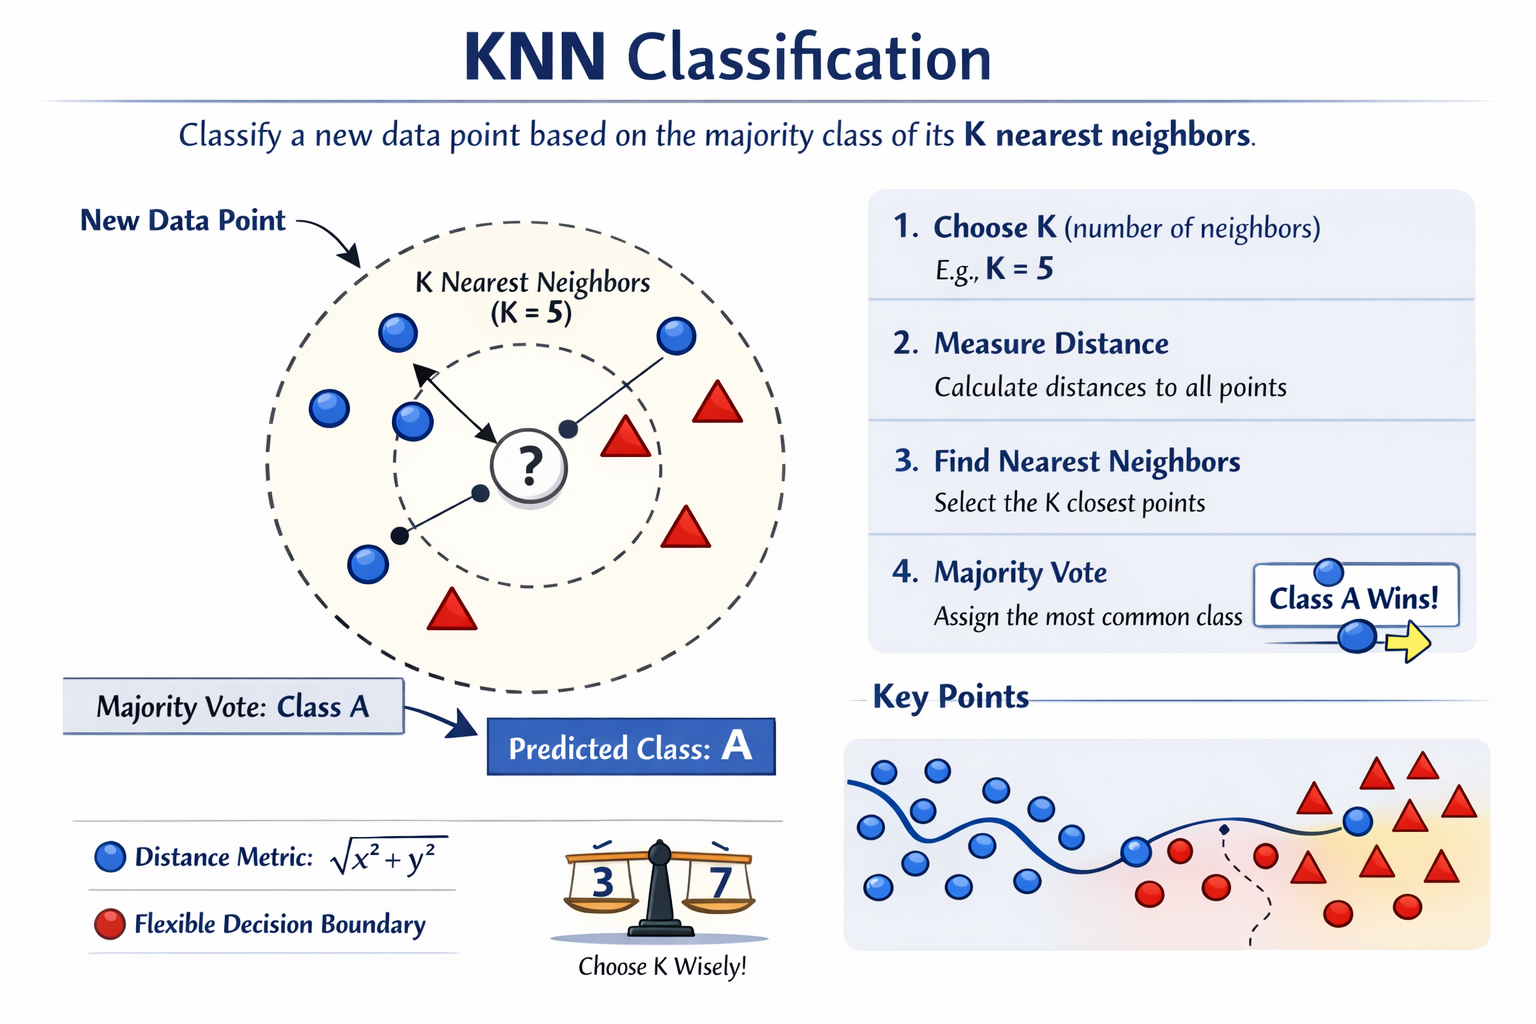

KNN Classification – Wine Quality (good / great / best)

In this section, the K-Nearest Neighbors (KNN) algorithm is applied to classify wine quality based on physicochemical attributes from the dataset winequality-red.csv. The original target variable, quality (ranging typically from 3 to 8), is transformed into a categorical variable with three classes: “good” (≤ 5), “great” (= 6), and “best” (≥ 7), representing increasing quality levels.

The workflow begins with loading and exploring the dataset, followed by creating a new categorical label (quality_label) from the original numeric target. The input features (X_cls) and corresponding labels (y_cls) are then defined. Since KNN relies on distance-based computations, feature scaling is applied to normalize the data. A KNeighborsClassifier model is subsequently trained on the processed dataset.

Model performance is evaluated using metrics such as accuracy and F1-score, along with a confusion matrix to analyze class-wise prediction behavior. This approach enables effective classification of wine quality while capturing similarities between samples in the feature space.

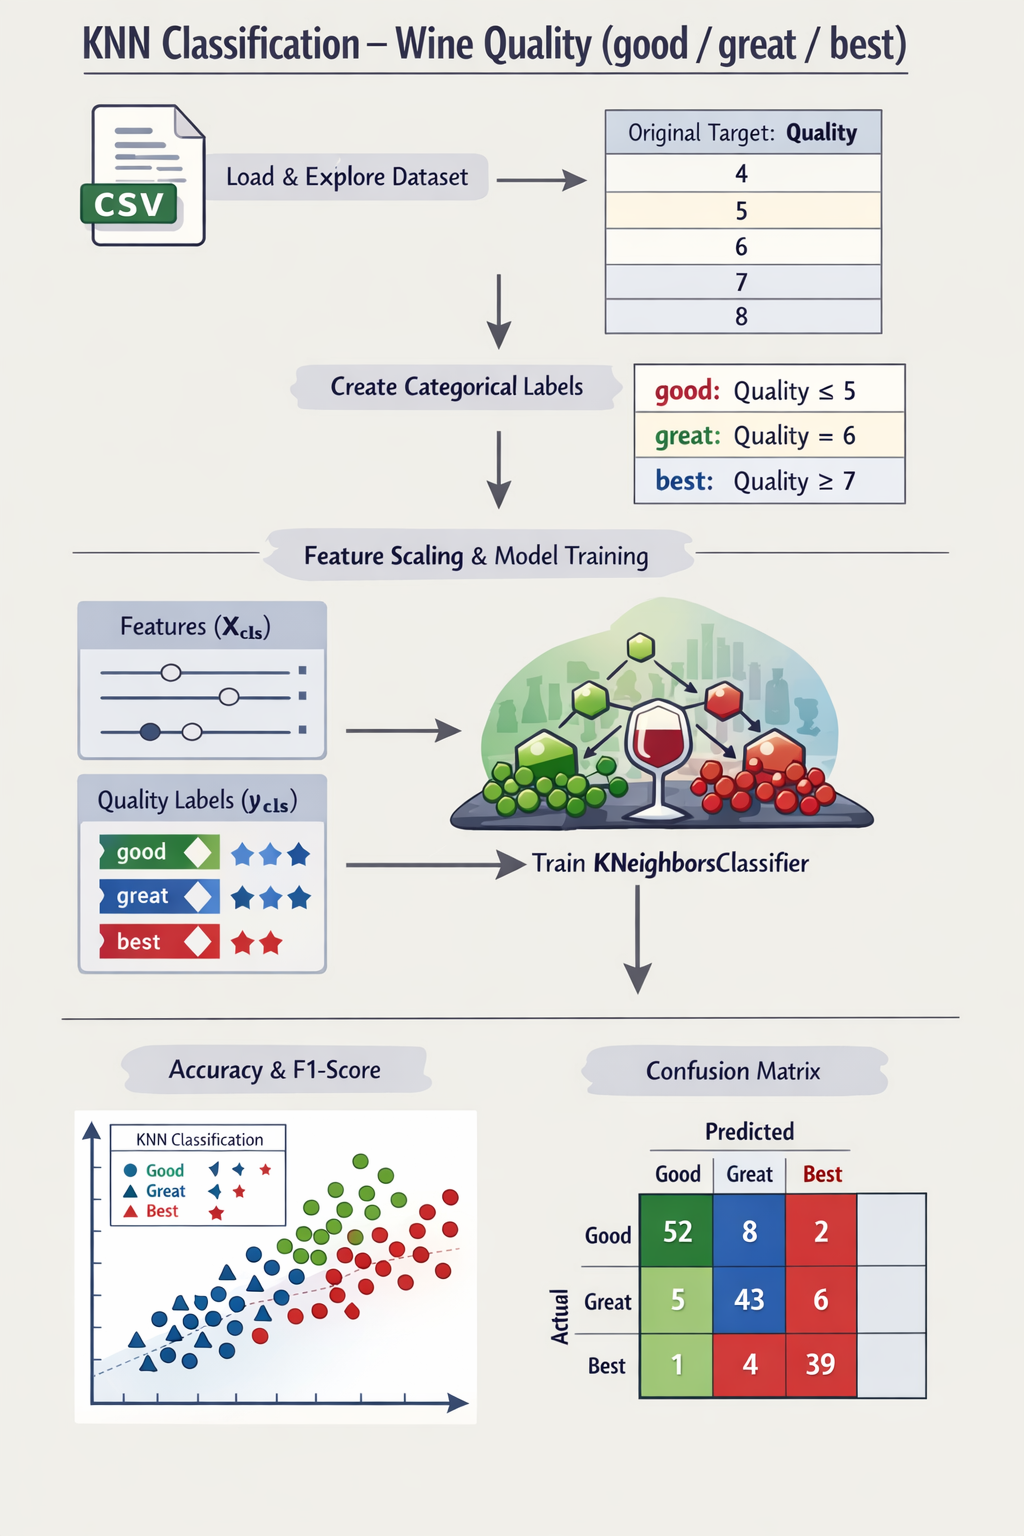

In [5]:
import pandas as pd

wine_df = pd.read_csv("/content/winequality-red (1).csv", sep=";")

print(wine_df.head())
print(wine_df["quality"].value_counts().sort_index())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

Lables

The numeric wine quality scores are transformed into categorical labels to simplify the classification task. Specifically, samples with a quality score of 5 or below are labeled as “good”, those with a score of 6 as “great”, and those with a score of 7 or higher as “best”. This mapping is stored in a new column called quality_label, enabling the model to perform multi-class classification instead of predicting continuous values.

In [6]:
def map_quality_to_label(q):
    if q <= 5:
        return "good"
    elif q == 6:
        return "great"
    else:  # q >= 7
        return "best"

wine_df["quality_label"] = wine_df["quality"].apply(map_quality_to_label)

print(wine_df[["quality", "quality_label"]].head())
print("\nLabel distribution:")
print(wine_df["quality_label"].value_counts())

   quality quality_label
0        5          good
1        5          good
2        5          good
3        6         great
4        5          good

Label distribution:
quality_label
good     744
great    638
best     217
Name: count, dtype: int64


The dataset is prepared for classification by defining the target and feature variables. The target variable (y_cls) is set as quality_label, representing the categorical classes (good, great, best). The feature set (X_cls) includes all original physicochemical attributes, excluding both the original quality column and the derived quality_label column. This ensures that only relevant input features are used for training the classification model.

In [7]:
# Target: 3-class labels
y_cls = wine_df["quality_label"]

# Features: all physicochemical properties
X_cls = wine_df.drop(columns=["quality", "quality_label"])

print("Features shape:", X_cls.shape)
print("Target shape:", y_cls.shape)
X_cls.head()

Features shape: (1599, 11)
Target shape: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


Train/Test Split (Classification)

The dataset is divided into training and testing subsets using a stratified split to maintain the original class distribution across both sets, ensuring balanced representation during model training and evaluation.

Feature Scaling

Since KNN relies on distance-based computations, feature scaling is applied to normalize the input variables. This ensures that all features contribute equally to distance calculations, preventing features with larger magnitudes from dominating the model and improving overall performance.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_scaler = StandardScaler()
X_cls_train_scaled = cls_scaler.fit_transform(X_cls_train)
X_cls_test_scaled = cls_scaler.transform(X_cls_test)


Train KNN Classifier

A K-Nearest Neighbors (KNN) Classifier is trained using the prepared dataset to predict wine quality categories. The model is configured with n_neighbors = 7, meaning each prediction is determined based on the seven closest data points in the feature space. Additionally, weights = "distance" assigns greater importance to nearer neighbors, allowing closer samples to have a stronger influence on the final classification decision.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_cls = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski"
)

knn_cls.fit(X_cls_train_scaled, y_cls_train)

print("KNN Classifier training complete.")


KNN Classifier training complete.


Evaluate KNN Classification

The performance of the KNN classifier is assessed using multiple evaluation metrics. Accuracy measures the overall proportion of correctly classified samples. Precision, recall, and F1-score are computed using macro-averaging to equally evaluate performance across all classes (good, great, and best). Additionally, a confusion matrix is used to visualize class-wise prediction outcomes, providing insight into how effectively the model distinguishes between the different wine quality categories.

KNN Classification – Metrics (macro average)
Accuracy : 0.716
Precision: 0.695
Recall   : 0.700
F1-score : 0.697

Classification Report:

              precision    recall  f1-score   support

        good       0.62      0.65      0.64        43
       great       0.80      0.74      0.77       149
        best       0.66      0.71      0.68       128

    accuracy                           0.72       320
   macro avg       0.69      0.70      0.70       320
weighted avg       0.72      0.72      0.72       320



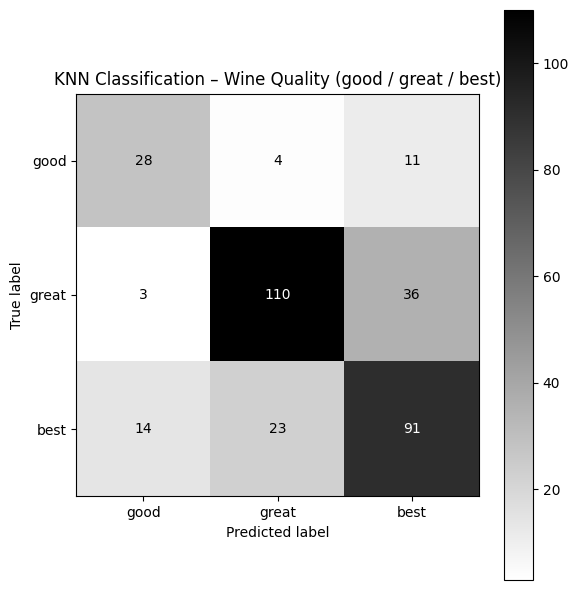

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions
y_cls_pred = knn_cls.predict(X_cls_test_scaled)

# Metrics (macro average for 3 classes)
acc = accuracy_score(y_cls_test, y_cls_pred)
prec = precision_score(y_cls_test, y_cls_pred, average="macro")
rec = recall_score(y_cls_test, y_cls_pred, average="macro")
f1 = f1_score(y_cls_test, y_cls_pred, average="macro")

print("KNN Classification – Metrics (macro average)")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}\n")

print("Classification Report:\n")
print(classification_report(y_cls_test, y_cls_pred, target_names=["good", "great", "best"]))

# Confusion matrix with high-contrast colormap
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_cls_test,
    y_cls_pred,
    display_labels=["good", "great", "best"],
    cmap="gist_yarg",
    ax=ax,
    colorbar=True
)
ax.set_title("KNN Classification – Wine Quality (good / great / best)")
plt.tight_layout()
plt.show()


KNN Classification – Evaluation Summary

The KNN classifier was applied to a three-class wine quality classification problem (“good,” “great,” and “best”) and achieved an overall accuracy of approximately 0.716, indicating that about 72% of samples were correctly classified. The macro-averaged precision, recall, and F1-scores (around 0.69–0.70) suggest reasonably balanced performance across all classes, without significant bias toward any single category. The classification report shows that the “great” class achieves the highest performance, likely due to its larger representation in the dataset, while the “good” and “best” classes exhibit slightly lower but still consistent results. The confusion matrix further reveals patterns of misclassification, particularly among adjacent quality levels, indicating overlap in feature characteristics.

Final Conclusion

The KNN classifier demonstrates reliable performance for multi-class wine quality prediction, achieving balanced accuracy and consistent macro-level metrics. It effectively leverages similarity in the feature space to classify samples, though some confusion persists between neighboring quality categories due to inherent overlap in the data. Overall, the model provides a robust baseline for this task, and further improvements could be achieved through hyperparameter tuning (e.g., optimizing k), experimenting with different distance metrics, or refining feature scaling techniques.